In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
small_cap = pd.read_csv("data/BSESML_01032016_16032026.csv")
mid_cap = pd.read_csv("data/BSEMID_01032016_16032026.csv")
large_cap = pd.read_csv("data/SPBSENIP_01032016_16032026.csv")

sector1 = pd.read_csv("data/INDDEF_01032016_16032026.csv")
sector2 = pd.read_csv("data/SI0800_01032016_16032026.csv")

print("Data Loaded ✅")

Data Loaded ✅


In [3]:
datasets = [small_cap, mid_cap, large_cap, sector1, sector2]

for df in datasets:
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values(by='Date', inplace=True)
    df.reset_index(drop=True, inplace=True)

print("Data Cleaning Done ✅")

Data Cleaning Done ✅


In [4]:
datasets = {
    "Small Cap": small_cap,
    "Mid Cap": mid_cap,
    "Large Cap": large_cap,
    "Defence": sector1,
    "Sector 2": sector2
}

for name, df in datasets.items():
    df.loc[df.sample(frac=0.05).index, 'Close'] = np.nan
    
    print(f"\n{name} Missing Before:")
    print(df.isnull().sum())
    
    df['Close'] = df['Close'].ffill()
    
    print(f"{name} Missing After:")
    print(df.isnull().sum())

print("\nMissing Values Handled ✅")


Small Cap Missing Before:
Date       0
Open       0
High       0
Low        0
Close    124
dtype: int64
Small Cap Missing After:
Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

Mid Cap Missing Before:
Date       0
Open       0
High       0
Low        0
Close    124
dtype: int64
Mid Cap Missing After:
Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

Large Cap Missing Before:
Date       0
Open       0
High       0
Low        0
Close    124
dtype: int64
Large Cap Missing After:
Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

Defence Missing Before:
Date     0
Open     0
High     0
Low      0
Close    7
dtype: int64
Defence Missing After:
Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

Sector 2 Missing Before:
Date       0
Open       0
High       0
Low        0
Close    124
dtype: int64
Sector 2 Missing After:
Date     0
Open     0
High     0
Low      0
Close    0
dtype: int64

Missing Values Handled ✅


In [5]:
large = large_cap[['Date', 'Close']].rename(columns={'Close': 'LargeCap'})
mid = mid_cap[['Date', 'Close']].rename(columns={'Close': 'MidCap'})
small = small_cap[['Date', 'Close']].rename(columns={'Close': 'SmallCap'})

combined = large.merge(mid, on='Date').merge(small, on='Date')

combined.head()

,Date,LargeCap,MidCap,SmallCap
0,2016-03-01,2387.93,9866.27,9856.56
1,2016-03-02,2413.62,9866.27,10073.97
2,2016-03-03,2442.21,10110.46,10209.66
3,2016-03-04,2453.04,10224.84,10285.75
4,2016-03-08,2488.32,10199.44,10309.98


In [6]:
sec1 = sector1[['Date', 'Close']].rename(columns={'Close': 'Defence'})
sec2 = sector2[['Date', 'Close']].rename(columns={'Close': 'Sector2'})

sector_combined = sec1.merge(sec2, on='Date')

sector_combined.head()

,Date,Defence,Sector2
0,2025-08-13,6623.97,43824.88
1,2025-08-14,6610.10,44453.35
2,2025-08-18,6653.54,44542.10
3,2025-08-19,6608.16,44589.54
4,2025-08-20,6579.23,44497.23


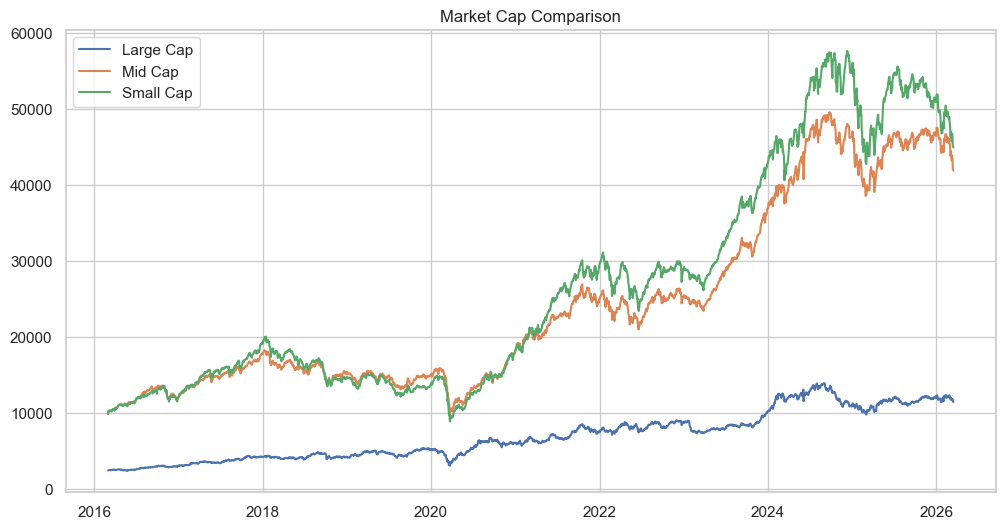

In [7]:
plt.figure(figsize=(12,6))

plt.plot(combined['Date'], combined['LargeCap'], label='Large Cap')
plt.plot(combined['Date'], combined['MidCap'], label='Mid Cap')
plt.plot(combined['Date'], combined['SmallCap'], label='Small Cap')

plt.title("Market Cap Comparison")
plt.legend()
plt.show()

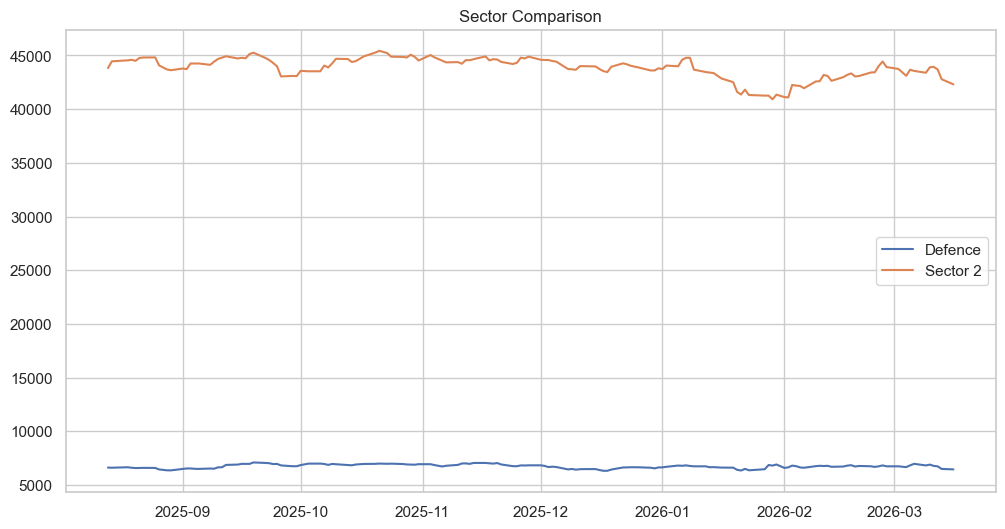

In [8]:
plt.figure(figsize=(12,6))

plt.plot(sector_combined['Date'], sector_combined['Defence'], label='Defence')
plt.plot(sector_combined['Date'], sector_combined['Sector2'], label='Sector 2')

plt.title("Sector Comparison")
plt.legend()
plt.show()

In [9]:
combined['Large_Return'] = combined['LargeCap'].pct_change()
combined['Mid_Return'] = combined['MidCap'].pct_change()
combined['Small_Return'] = combined['SmallCap'].pct_change()

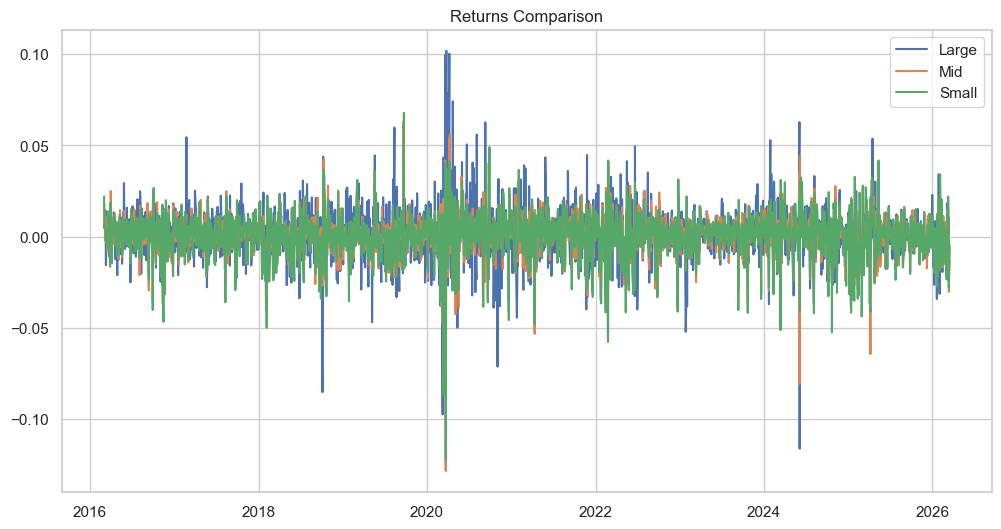

In [10]:
plt.figure(figsize=(12,6))

plt.plot(combined['Date'], combined['Large_Return'], label='Large')
plt.plot(combined['Date'], combined['Mid_Return'], label='Mid')
plt.plot(combined['Date'], combined['Small_Return'], label='Small')

plt.title("Returns Comparison")
plt.legend()
plt.show()

In [11]:
volatility = {
    "Large": combined['Large_Return'].std(),
    "Mid": combined['Mid_Return'].std(),
    "Small": combined['Small_Return'].std()
}

print(volatility)

{'Large': 0.014339605244763133, 'Mid': 0.011245621810046224, 'Small': 0.01168659149362366}


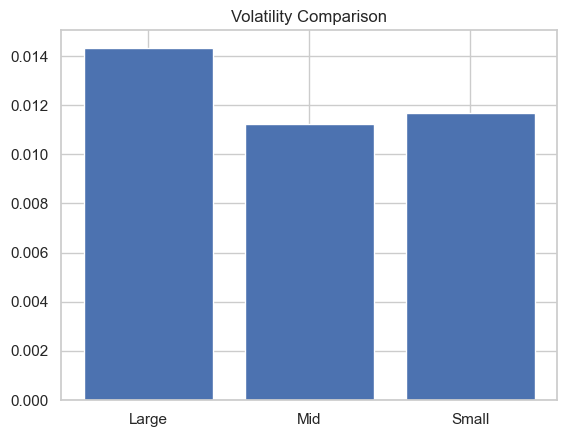

In [12]:
plt.bar(volatility.keys(), volatility.values())
plt.title("Volatility Comparison")
plt.show()

In [13]:
corr = combined[['LargeCap', 'MidCap', 'SmallCap']].corr()
print(corr)

          LargeCap    MidCap  SmallCap
LargeCap  1.000000  0.960309  0.956868
MidCap    0.960309  1.000000  0.997039
SmallCap  0.956868  0.997039  1.000000


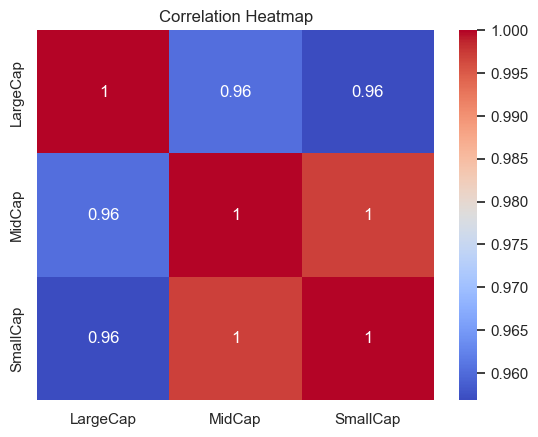

In [14]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

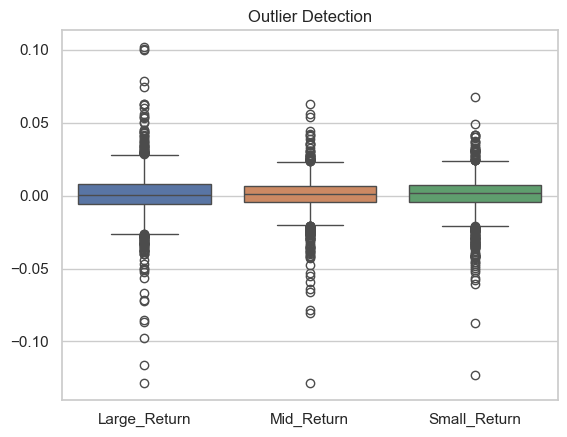

In [15]:
sns.boxplot(data=combined[['Large_Return','Mid_Return','Small_Return']])
plt.title("Outlier Detection")
plt.show()

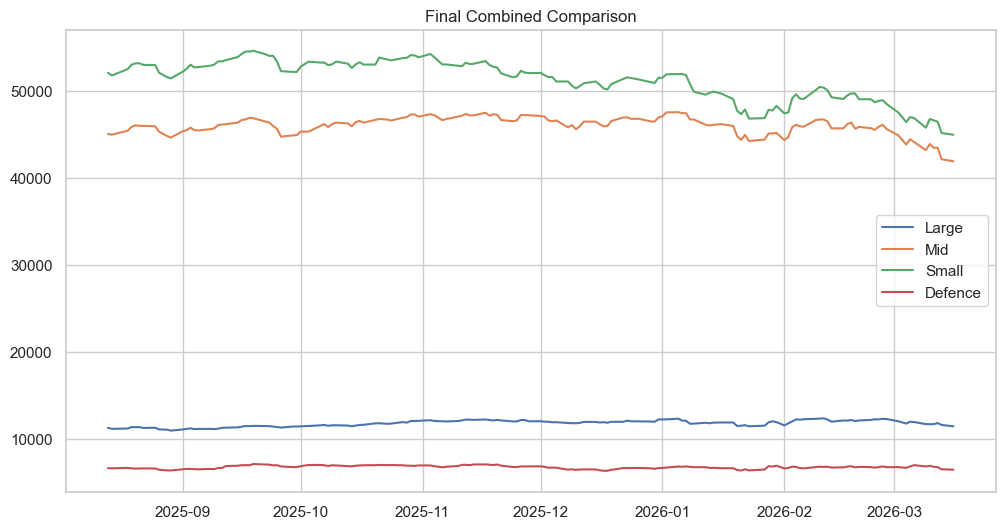

In [16]:
final_df = combined.merge(sector_combined, on='Date')

plt.figure(figsize=(12,6))

plt.plot(final_df['Date'], final_df['LargeCap'], label='Large')
plt.plot(final_df['Date'], final_df['MidCap'], label='Mid')
plt.plot(final_df['Date'], final_df['SmallCap'], label='Small')
plt.plot(final_df['Date'], final_df['Defence'], label='Defence')

plt.title("Final Combined Comparison")
plt.legend()
plt.show()

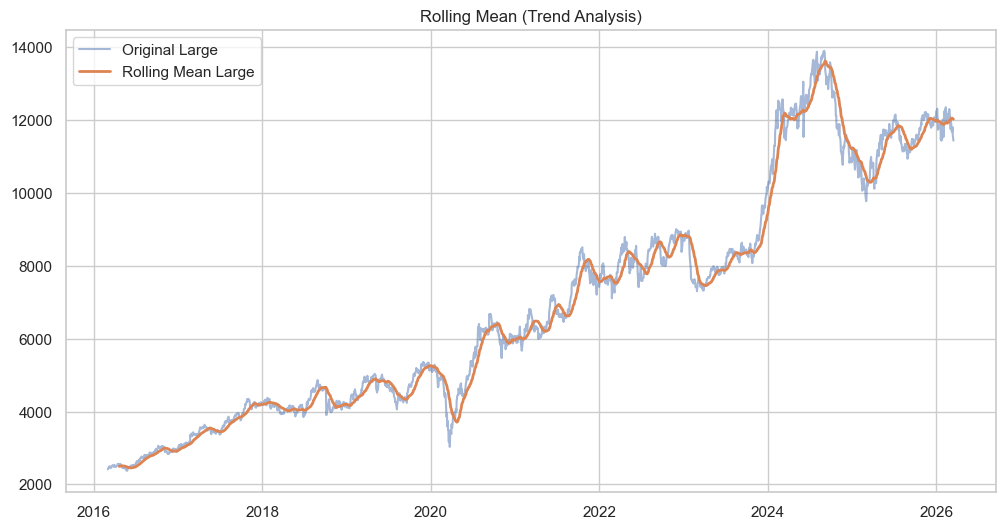

In [19]:
# ================================
# ROLLING MEAN (30 DAYS)
# ================================

combined['Large_Rolling'] = combined['LargeCap'].rolling(window=30).mean()
combined['Mid_Rolling'] = combined['MidCap'].rolling(window=30).mean()
combined['Small_Rolling'] = combined['SmallCap'].rolling(window=30).mean()

plt.figure(figsize=(12,6))

plt.plot(combined['Date'], combined['LargeCap'], label='Original Large', alpha=0.5)
plt.plot(combined['Date'], combined['Large_Rolling'], label='Rolling Mean Large', linewidth=2)

plt.title("Rolling Mean (Trend Analysis)")
plt.legend()
plt.show()

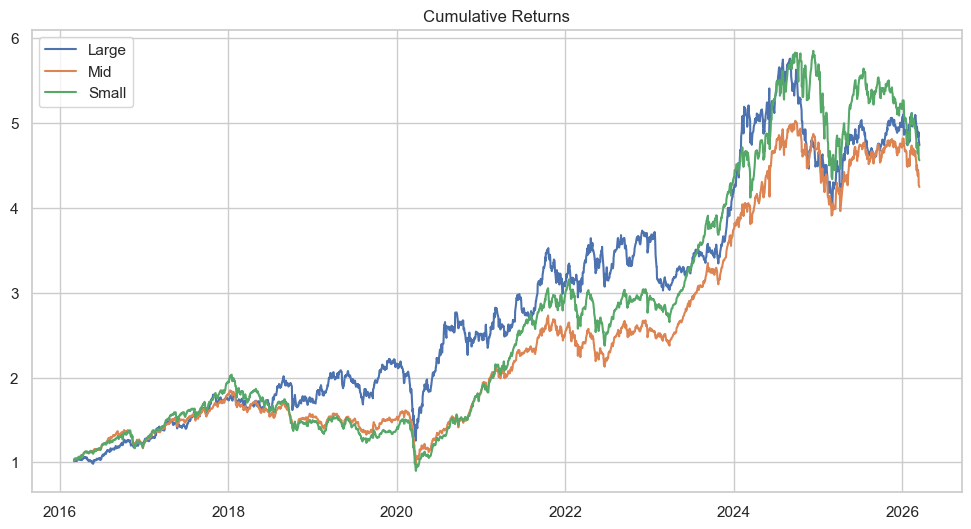

In [20]:
# ================================
# CUMULATIVE RETURNS
# ================================

cum_returns = (1 + combined[['Large_Return','Mid_Return','Small_Return']]).cumprod()

plt.figure(figsize=(12,6))

plt.plot(combined['Date'], cum_returns['Large_Return'], label='Large')
plt.plot(combined['Date'], cum_returns['Mid_Return'], label='Mid')
plt.plot(combined['Date'], cum_returns['Small_Return'], label='Small')

plt.title("Cumulative Returns")
plt.legend()
plt.show()

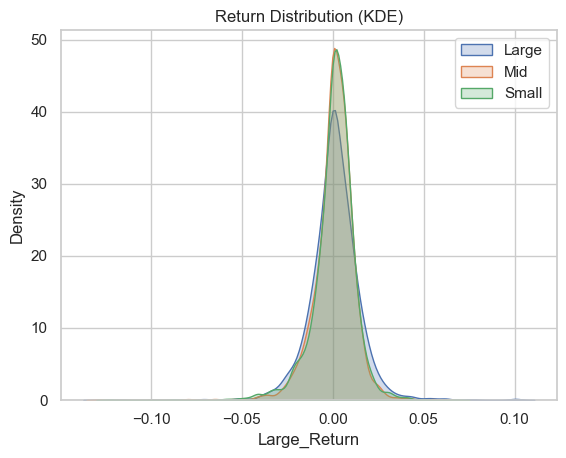

In [21]:
# ================================
# KDE PLOT
# ================================

sns.kdeplot(combined['Large_Return'], label='Large', fill=True)
sns.kdeplot(combined['Mid_Return'], label='Mid', fill=True)
sns.kdeplot(combined['Small_Return'], label='Small', fill=True)

plt.title("Return Distribution (KDE)")
plt.legend()
plt.show()

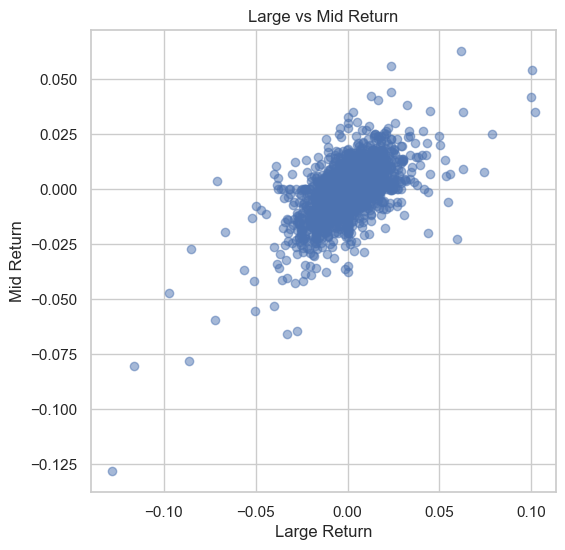

In [22]:
# ================================
# SCATTER PLOT
# ================================

plt.figure(figsize=(6,6))

plt.scatter(combined['Large_Return'], combined['Mid_Return'], alpha=0.5)

plt.title("Large vs Mid Return")
plt.xlabel("Large Return")
plt.ylabel("Mid Return")

plt.show()

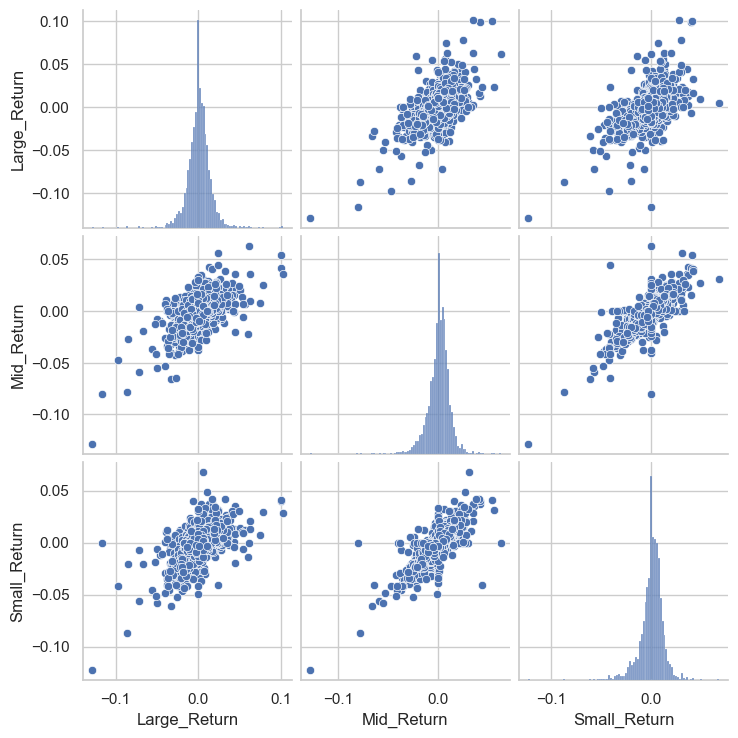

In [23]:
# ================================
# PAIRPLOT
# ================================

sns.pairplot(combined[['Large_Return','Mid_Return','Small_Return']])
plt.show()

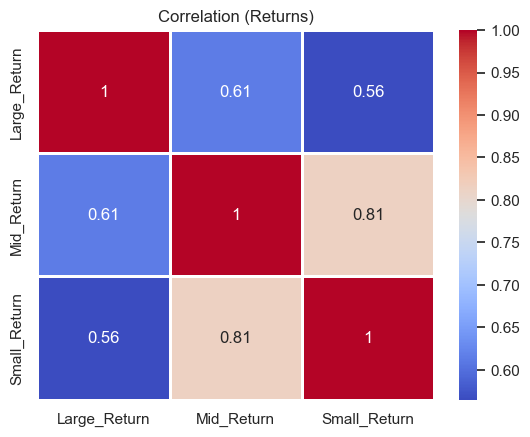

In [24]:
# ================================
# ADVANCED HEATMAP
# ================================

sns.heatmap(combined[['Large_Return','Mid_Return','Small_Return']].corr(),
            annot=True, cmap='coolwarm', linewidths=1)

plt.title("Correlation (Returns)")
plt.show()

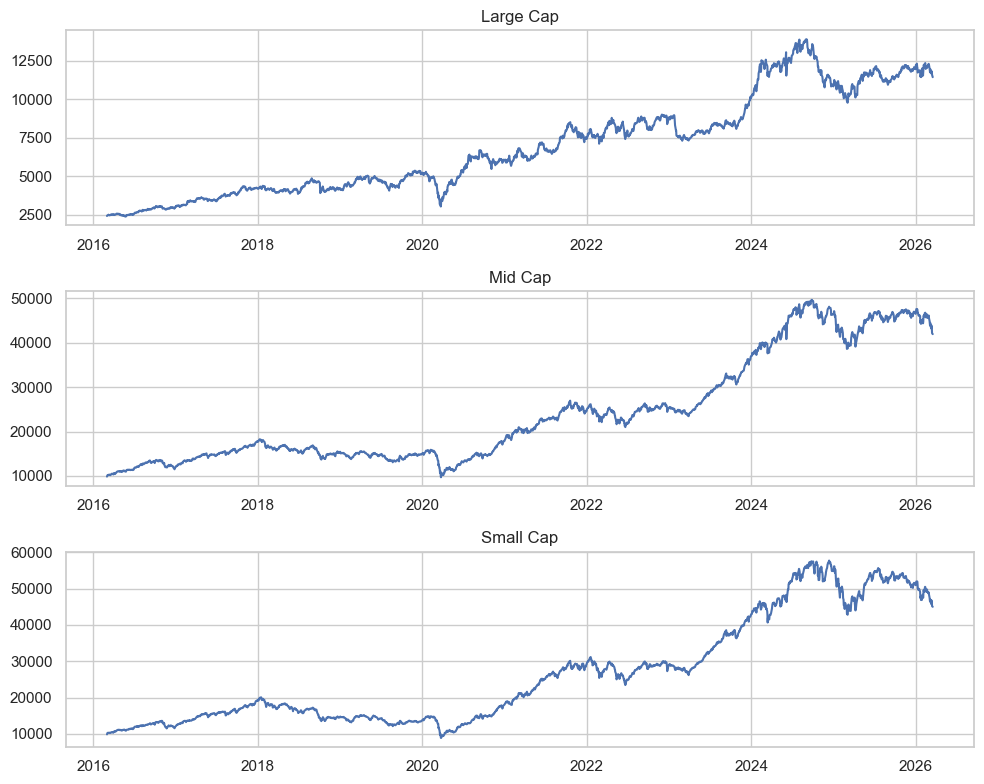

In [25]:
# ================================
# SUBPLOTS
# ================================

fig, axes = plt.subplots(3, 1, figsize=(10,8))

axes[0].plot(combined['Date'], combined['LargeCap'])
axes[0].set_title("Large Cap")

axes[1].plot(combined['Date'], combined['MidCap'])
axes[1].set_title("Mid Cap")

axes[2].plot(combined['Date'], combined['SmallCap'])
axes[2].set_title("Small Cap")

plt.tight_layout()
plt.show()

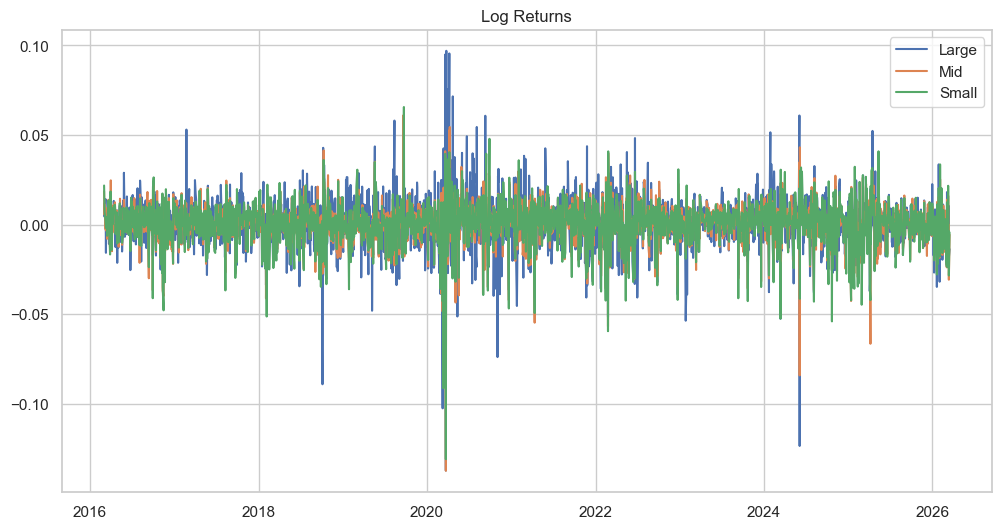

In [26]:
# ================================
# LOG RETURNS
# ================================

combined['Large_Log'] = np.log(combined['LargeCap'] / combined['LargeCap'].shift(1))
combined['Mid_Log'] = np.log(combined['MidCap'] / combined['MidCap'].shift(1))
combined['Small_Log'] = np.log(combined['SmallCap'] / combined['SmallCap'].shift(1))

plt.figure(figsize=(12,6))

plt.plot(combined['Date'], combined['Large_Log'], label='Large')
plt.plot(combined['Date'], combined['Mid_Log'], label='Mid')
plt.plot(combined['Date'], combined['Small_Log'], label='Small')

plt.title("Log Returns")
plt.legend()
plt.show()

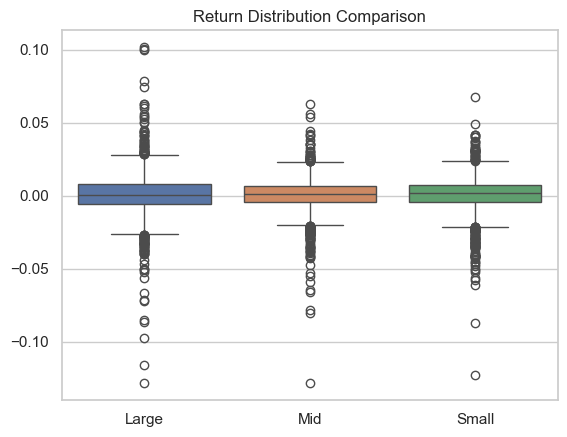

In [27]:
# ================================
# BOXPLOT (BETTER)
# ================================

df_box = combined[['Large_Return','Mid_Return','Small_Return']]

df_box.columns = ['Large','Mid','Small']

sns.boxplot(data=df_box)
plt.title("Return Distribution Comparison")
plt.show()

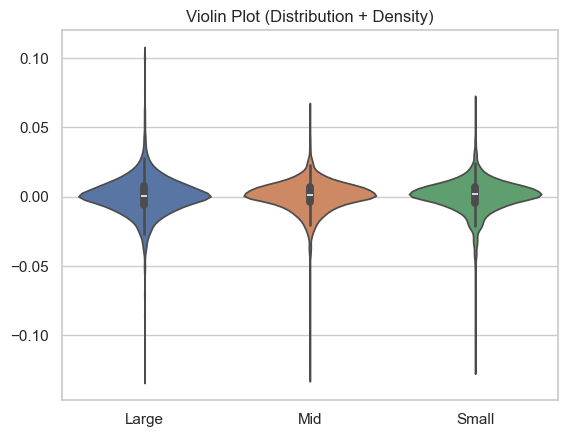

In [28]:
# ================================
# VIOLIN PLOT
# ================================

sns.violinplot(data=df_box)

plt.title("Violin Plot (Distribution + Density)")
plt.show()

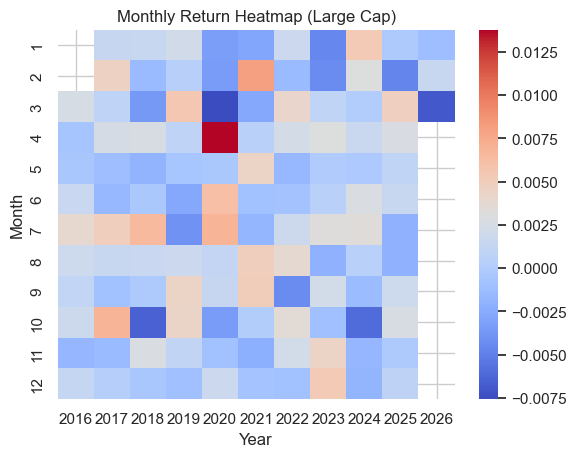

In [29]:
# ================================
# MONTHLY HEATMAP
# ================================

combined['Year'] = combined['Date'].dt.year
combined['Month'] = combined['Date'].dt.month

pivot = combined.pivot_table(values='Large_Return', index='Month', columns='Year')

sns.heatmap(pivot, cmap='coolwarm')

plt.title("Monthly Return Heatmap (Large Cap)")
plt.show()

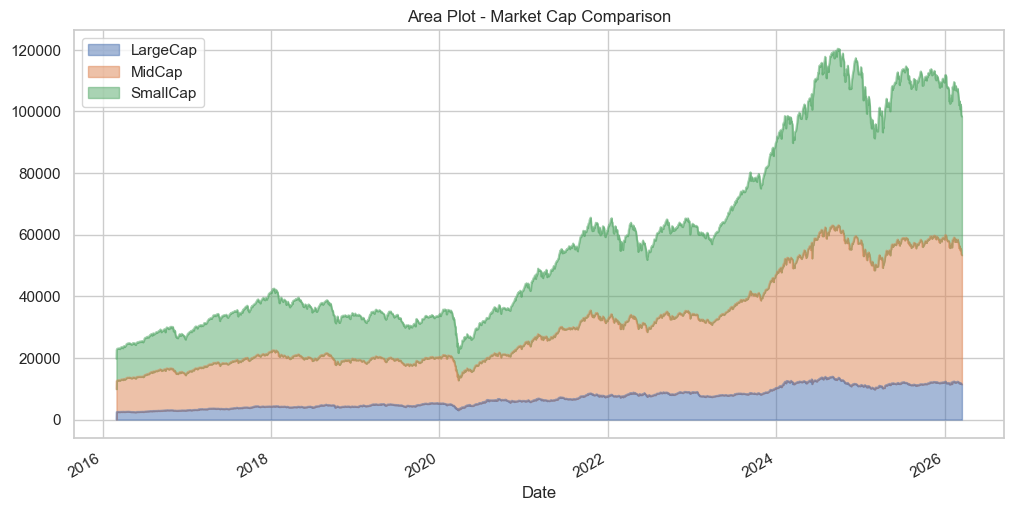

In [30]:
# ================================
# AREA PLOT
# ================================

combined.set_index('Date')[['LargeCap','MidCap','SmallCap']].plot.area(figsize=(12,6), alpha=0.5)

plt.title("Area Plot - Market Cap Comparison")
plt.show()

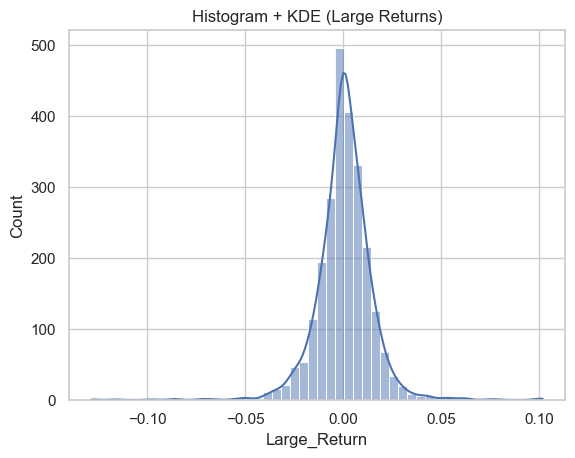

In [31]:
# ================================
# HISTOGRAM + KDE
# ================================

sns.histplot(combined['Large_Return'], kde=True, bins=50)

plt.title("Histogram + KDE (Large Returns)")
plt.show()

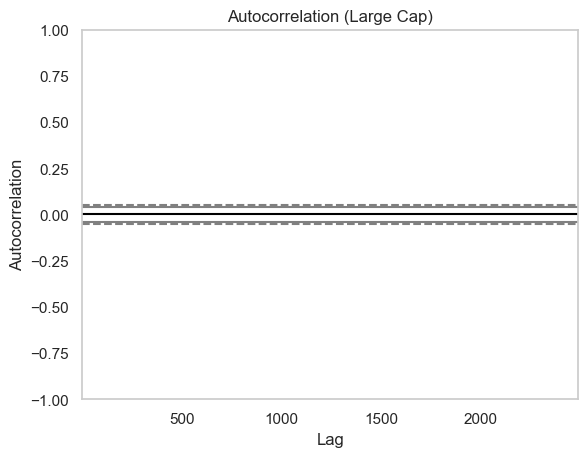

In [32]:
# ================================
# AUTOCORRELATION
# ================================

from pandas.plotting import autocorrelation_plot

autocorrelation_plot(combined['LargeCap'])

plt.title("Autocorrelation (Large Cap)")
plt.show()

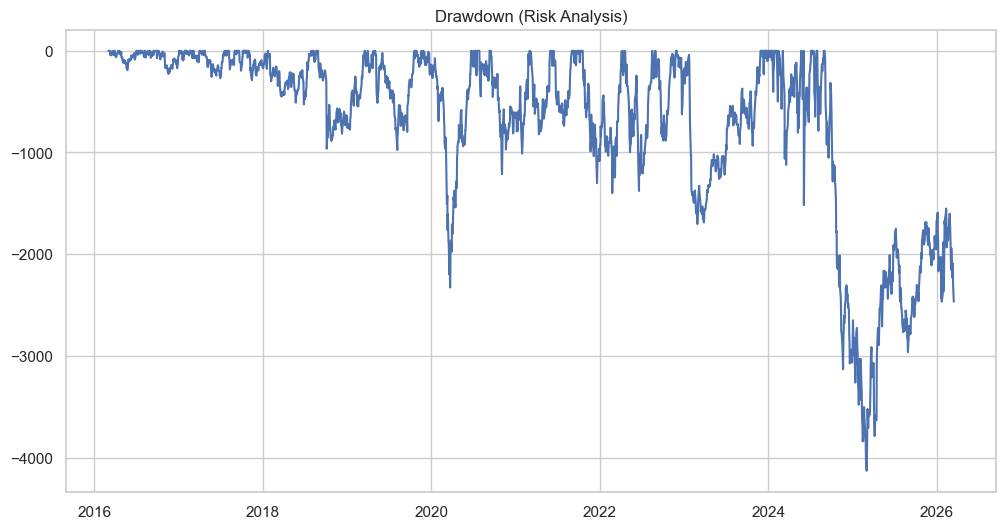

In [33]:
# ================================
# DRAWDOWN
# ================================

cum_max = combined['LargeCap'].cummax()
drawdown = combined['LargeCap'] - cum_max

plt.figure(figsize=(12,6))

plt.plot(combined['Date'], drawdown)

plt.title("Drawdown (Risk Analysis)")
plt.show()

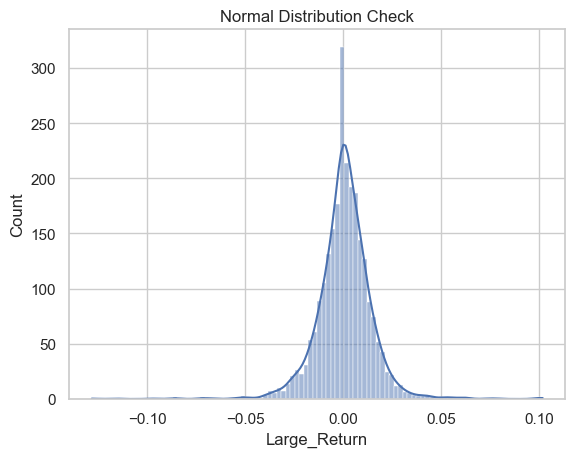

In [34]:
# ================================
# NORMAL DISTRIBUTION CHECK
# ================================

sns.histplot(combined['Large_Return'], kde=True)

plt.title("Normal Distribution Check")
plt.show()

In [35]:
# ================================
# SHAPIRO TEST
# ================================

from scipy.stats import shapiro

stat, p = shapiro(combined['Large_Return'].dropna())

print("Shapiro Test:")
print("Statistic:", stat)
print("p-value:", p)

Shapiro Test:
Statistic: 0.9005912382128151
p-value: 1.887112903021327e-37


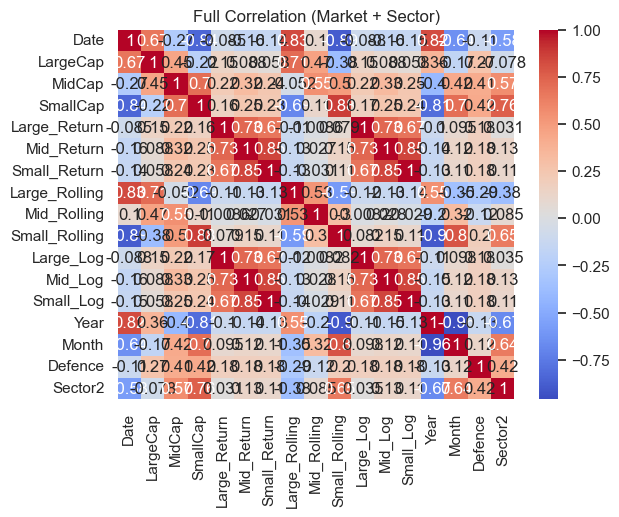

In [36]:
# ================================
# SECTOR + MARKET CORRELATION
# ================================

final_df = combined.merge(sector_combined, on='Date')

corr_all = final_df.corr()

sns.heatmap(corr_all, annot=True, cmap='coolwarm')

plt.title("Full Correlation (Market + Sector)")
plt.show()

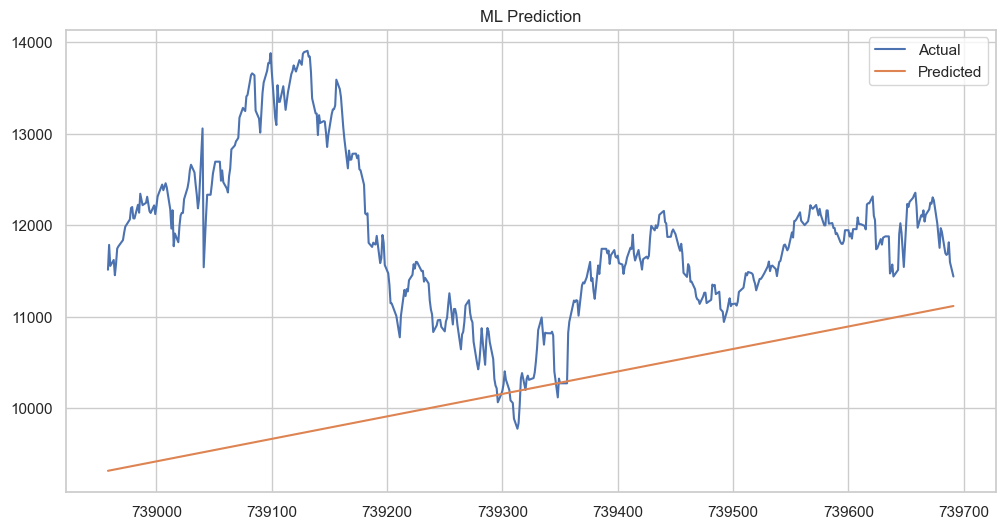

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

ml_data = combined[['Date', 'LargeCap']].copy()

# convert Date
ml_data['Date'] = ml_data['Date'].map(pd.Timestamp.toordinal)

# 🔥 REMOVE NaN VALUES (IMPORTANT FIX)
ml_data = ml_data.dropna()

X = ml_data[['Date']]
y = ml_data['LargeCap']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(12,6))
plt.plot(X_test, y_test, label='Actual')
plt.plot(X_test, y_pred, label='Predicted')
plt.legend()
plt.title("ML Prediction")
plt.show()